In [1]:
%load_ext autoreload
%autoreload 2

This notebook documents the processing and harmonisation of the earthquake databases used for the record selection

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
from openquake.hazardlib.imt import AvgSA, SA, PGA, RSD595, IA
import matplotlib.pyplot as plt

from pickagm import eqdbases as eqdb
from pickagm import dfops 
from phd_project.config.config import load_config 
import phd_project.scripts.WP1_ground_motion_set.manage_flatfiles as mf
cfg = load_config()

In [ ]:
# set some parameters
imts_to_keep = tuple(
    [AvgSA([0,3]).name, RSD595().name, PGA().name, SA(1.00).name, IA().name])  # strings match



# ESM

In [ ]:
esm_fp = cfg["raw_data"]["esm_flatfile"]
im_start_idx = 71
components = ["U", "V"]
desired_metadata = ["index", "database", "event_id", "event_time", "station_code", 
                    "location_code", "trt", "mag", "rjb", "vs30",
                    "max_usable_T", "component"]

# previously selected records that failed to download from esm database
# these need to be removed from the flatfile before selecting records
esm_failed_downloads_fp = Path(cfg['paths']['esm_failed_downloads'])

In [ ]:
esm_original = mf.load_esm_flatfile(esm_fp)  # loaded with all values as strings

failed_downloads = 

metadata = eqdb.extract_metadata(esm_original, im_start_idx)
imdata = eqdb.extract_im_data(esm_original, im_start_idx)
metadata = mf.label_record_trts_esm(metadata) # add the trt type to each record
im_start_idx += 1         # one new column added


In [6]:
# rename the im columns
imdata = eqdb.rename_sa_columns_esm(imdata)
imdata.columns = pd.MultiIndex.from_tuples(
    [(c.split("_")[0], c.split("_")[1]) for c in imdata.columns])

# keep only U-V components of the records remove the rest
imdata = imdata[components]
imdata = imdata.astype(np.float64)

In [7]:
# stack arrays and add index and component columns
dfs = [pd.concat([metadata.assign(component=c), imdata[c]], axis=1) 
        for c in components]
df = pd.concat(dfs, axis=0)         # stack dfs vertically
df = df.reset_index() 
im_start_idx += 2           # two new columns added

In [8]:
# translate column names to OpenQuake IMT strings
columns = []
for c in df.columns:
    try:
        new_col = eqdb.esm_nonSA_im_translations[c]
    except KeyError:
        new_col = c
    columns.append(new_col)
df.columns = columns

In [9]:
# make PGA absolute
df["PGA"] = np.abs(df["PGA"])

# add the AvgSA([0, 3]) and AvgSA([0, 6]) columns
metadata = eqdb.extract_metadata(df, im_start_idx)
imdata = eqdb.extract_im_data(df, im_start_idx)
AvgSA_tags = ["AvgSA([0, 3])", "AvgSA([0, 6])"]
AvgSA_periods = [np.round(np.linspace(0, 3, 10), 3), 
                 np.round(np.linspace(0, 6, 10), 3)]

imdata = mf.add_AvgSA_columns2(imdata, AvgSA_tags, AvgSA_periods)    

# scale ims to desired units
imdata = mf.scale_cols(imdata, eqdb.esm_unit_conversions)

# drop unneeded ims
imdata = imdata[[c for c in imdata.columns if c.startswith(imts_to_keep)]]

# get the sa periods
sa_periods = mf.get_SA_periods_from_headers(df)


In [10]:
# organise the metadata and multiindex
metadata.loc[:, "max_usable_T"] = 0.8 / metadata[["U_hp", "V_hp"]].apply(pd.to_numeric).min(axis=1).copy()
metadata.loc[:, "mag"] = metadata["EMEC_Mw"].combine_first(metadata["Mw"]).copy()
metadata.loc[:, "rjb"] = metadata["JB_dist"].combine_first(metadata["epi_dist"]).copy()
metadata.loc[:, "vs30"] = metadata["vs30_m_sec"].combine_first(metadata["vs30_m_sec_WA"]).copy()
metadata.loc[:, "database"] = "ESM"
metadata = metadata[desired_metadata]
metadata.columns = pd.MultiIndex.from_tuples(
    [("metadata", c) for c in metadata.columns])
imdata.columns = pd.MultiIndex.from_tuples(
    [("ims", c) for c in imdata.columns])
df = pd.concat([metadata, imdata], axis=1)
esm = df.dropna(axis=0)
esm = esm.astype({
    ("metadata", "vs30"): np.float64,
    ("metadata", "rjb"): np.float64,
    ("metadata", "mag"): np.float64
})

# remove any records with zero duration
esm = esm.loc[esm[("ims", "RSD595")] > 0, :]
# remove any records with location code not == 0
esm = esm.loc[esm[("metadata", "location_code")] == "00", :]

esm_dtypes = esm.dtypes

In [13]:
# save the final dataframe
esm.to_csv(cfg["proc_data"]["gm_databases_for_selection"] / "esm_records.csv", 
          sep=",", index=False)

# NGA-Sub

In [14]:
# load the data
ngasub_meta_fp = cfg["raw_data"]["gm_flatfiles"] / "NGASub_Metadata_SA_rotD50.csv"

ngasub_SA_H1_fp = cfg["raw_data"]["gm_flatfiles"] / "NGASub_SA_H1.csv"
ngasub_SA_H2_fp = cfg["raw_data"]["gm_flatfiles"] / "NGASub_SA_H2.csv"
ngasub_Duration_fp = cfg["raw_data"]["gm_flatfiles"] / "NGASub_duration_metrics_H1H2V.csv"

# components = ["U", "V"]
metadata_rename = {"NGAsubRSN":"index", "NGAsubEQID": "event_id", 
                   "NGAsubSSN": "station_code",
                   "Earthquake_Magnitude": "mag", 
                   "Intra_Inter_Flag": "trt",
                   "Rjb_km": "rjb", "Vs30_Selected_for_Analysis_m_s": "vs30",
                   "Longest_Usable_Period_for_PSa_Ave_Component_sec":"max_usable_T", 
                   }
trt_map = {0: "Subduction Interface",
           1: "Subduction Inslab"}

In [15]:
df_meta = pd.read_csv(ngasub_meta_fp, header=0, encoding="cp1252", 
                      dtype={"Interface_Event_FromHypocenterDepth": str,
                             "Instrument_Type": str,
                             "Geomatrix_Site_Code_1st_Letter": str})
df_meta = df_meta.iloc[:, 0:84]

In [16]:
# rename some columns and add some dummy metadata to match the columns in ESM
df_meta = df_meta.rename(columns=metadata_rename)
df_meta.loc[:, "database"] = "NGASub"
df_meta.loc[:, "event_time"] = "YYYY-MM-DD HH:MM:00"
df_meta.loc[:, "location_code"] = 0
df_meta.loc[:, "component"] = "H"
df_meta = df_meta[desired_metadata]
df_meta.columns = pd.MultiIndex.from_product([["metadata"], df_meta.columns])

In [17]:
# load the H1 spectral acceleration values
df_SA1 = pd.read_csv(ngasub_SA_H1_fp, header=0, encoding="cp1252", 
                      dtype={"Interface_Event_FromHypocenterDepth": str,
                             "Instrument_Type": str,
                             "Geomatrix_Site_Code_1st_Letter": str})
df_SA1 = df_SA1.iloc[:, 12:]
df_SA1 = df_SA1.drop(columns=["PGV_cm_sec", "PGD_cm"])

# rename the columns
new_sa_cols = ["PGA"] + [f"SA({c.split("pt")[0][1:]}.{c.split("pt")[1][:-1]})" for c in df_SA1.columns[1:]]
df_SA1.columns = new_sa_cols

# interpolate for the periods that we actually want
df_SA1 = df_SA1.replace(-999, np.nan)
interped_SA_1 = mf.interpolate_SA_values(df_SA1, sa_periods)

# calculate the average spectral acceleration
AvgSA_tags = ["AvgSA([0, 3])", "AvgSA([0, 6])"]
AvgSA_periods = [np.round(np.linspace(0, 3, 10), 3), 
                 np.round(np.linspace(0, 6, 10), 3)]

AvgSA_1 = mf.add_AvgSA_columns2(df_SA1, AvgSA_tags, AvgSA_periods)[AvgSA_tags] 


In [18]:
# load the H2 spectral acceleration values
df_SA2 = pd.read_csv(ngasub_SA_H2_fp, header=0, encoding="cp1252", 
                      dtype={"Interface_Event_FromHypocenterDepth": str,
                             "Instrument_Type": str,
                             "Geomatrix_Site_Code_1st_Letter": str})
df_SA2 = df_SA2.iloc[:, 12:]
df_SA2 = df_SA2.drop(columns=["PGV_cm_sec", "PGD_cm"])

# rename the columns
new_sa_cols = ["PGA"] + [f"SA({c.split("pt")[0][1:]}.{c.split("pt")[1][:-1]})" for c in df_SA2.columns[1:]]
df_SA2.columns = new_sa_cols

# interpolate for the periods that we actually want
df_SA2 = df_SA2.replace(-999, np.nan)
interped_SA_2 = mf.interpolate_SA_values(df_SA2, sa_periods)

# calculate the average spectral acceleration
AvgSA_2 = mf.add_AvgSA_columns2(df_SA2, AvgSA_tags, AvgSA_periods)[AvgSA_tags] 


In [19]:
# Load duration metrics
df_Dur = pd.read_csv(ngasub_Duration_fp, header=0, encoding="cp1252")
rsd595_1 = df_Dur["H1_Duration_0pt05_0pt95"]
rsd595_2 = df_Dur["H2_Duration_0pt05_0pt95"] 
ai_1 = df_Dur["H1_Arias_Intensity_m_s_tot"]  
ai_2 = df_Dur["H2_Arias_Intensity_m_s_tot"] 

In [20]:
# Stack 'em all together
H1_ims = pd.concat([rsd595_1.rename("RSD595"), ai_1.rename("IA"), AvgSA_1, df_SA1["PGA"], interped_SA_1], axis=1)
H1_ims.columns = pd.MultiIndex.from_product([["ims"], H1_ims.columns])
H2_ims = pd.concat([rsd595_2.rename("RSD595"), ai_2.rename("IA"), AvgSA_2, df_SA2["PGA"], interped_SA_2], axis=1)
H2_ims.columns = pd.MultiIndex.from_product([["ims"], H2_ims.columns])

H1_df = pd.concat([df_meta, H1_ims], axis=1)
H1_df[("metadata", "component")] = "H1"
H2_df = pd.concat([df_meta, H2_ims], axis=1)
H2_df[("metadata", "component")] = "H2"

NGAsub = pd.concat([H1_df, H2_df], axis=0)

# filter the TRT to only use Interface "0" and Inslab "1" events
mask = (NGAsub[("metadata", "trt")] == 0) | (NGAsub[("metadata", "trt")] == 1)
NGAsub = NGAsub.loc[mask, :]

# replace the trt integers with names
NGAsub[("metadata", "trt")] = NGAsub[("metadata", "trt")].replace(0, "Subduction Interface")
NGAsub[("metadata", "trt")] = NGAsub[("metadata", "trt")].replace(1, "Subduction Inslab")

# tweak the types to match esm df
NGAsub = NGAsub.astype(esm_dtypes)

# replace -999 with nan
NGAsub[("metadata", "vs30")] = NGAsub[("metadata", "vs30")].replace(-999, np.nan)
NGAsub[("metadata", "rjb")] = NGAsub[("metadata", "rjb")].replace(-999, np.nan)
NGAsub[("metadata", "max_usable_T")] = NGAsub[("metadata", "max_usable_T")].replace(-999, np.nan)
NGAsub = NGAsub.dropna(axis=0)

# remove records where the duration is 0.0s
NGAsub = NGAsub.loc[NGAsub[("ims", "RSD595")] > 0, :]

In [21]:
# check that all the columns are the same
all(NGAsub.columns.sort_values() == esm.columns.sort_values())

True

In [22]:
# save the final dataframe
NGAsub.to_csv(cfg["proc_data"]["gm_databases_for_selection"] / "NGAsub_records.csv", 
          sep=",", index=False)

In [23]:
NGAsub

metadata                    ...       ims                    
         index database event_id  ...   SA(8.0)   SA(9.0)  SA(10.0)
0      1000001   NGASub  1000001  ...  0.000064  0.000086  0.000094
1      1000002   NGASub  1000001  ...  0.000407  0.000299  0.000259
2      1000003   NGASub  1000001  ...  0.000086  0.000089  0.000080
3      1000004   NGASub  1000001  ...  0.000057  0.000042  0.000048
4      1000005   NGASub  1000001  ...  0.000167  0.000133  0.000123
...        ...      ...      ...  ...       ...       ...       ...
70872  7012036   NGASub  7000074  ...  0.000022  0.000015  0.000009
70873  7012037   NGASub  7000074  ...  0.000072  0.000066  0.000061
70874  7012038   NGASub  7000074  ...  0.000057  0.000042  0.000027
70875  7012039   NGASub  7000074  ...  0.000035  0.000034  0.000032
70876  7012040   NGASub  7000074  ...  0.000033  0.000039  0.000040

[88154 rows x 53 columns]

# Final Database

In [25]:
final_db = pd.concat([esm, NGAsub], axis=0)

# save the final dataframe
final_db.to_csv(cfg["proc_data"]["gm_databases_for_selection"] / "ESM-NGAsub_combined.csv", 
          sep=",", index=False)

In [26]:
final_db

metadata                         ...           ims                            
         index database      event_id  ...      SA(10.0) AvgSA([0, 3]) AvgSA([0, 6])
0            0      ESM  AL-2014-0005  ...  1.530071e-06      0.000076      0.000026
1            1      ESM  AL-2014-0005  ...  4.852192e-07      0.000026      0.000009
2            2      ESM  AL-2014-0005  ...  2.915392e-07      0.000018      0.000006
10          10      ESM  AL-2016-0003  ...  1.466871e-06      0.000045      0.000021
11          11      ESM  AL-2016-0004  ...  8.593272e-07      0.000073      0.000020
...        ...      ...           ...  ...           ...           ...           ...
70872  7012036   NGASub       7000074  ...  9.193440e-06      0.000147      0.000078
70873  7012037   NGASub       7000074  ...  6.076880e-05      0.004157      0.001236
70874  7012038   NGASub       7000074  ...  2.718340e-05      0.001650      0.000541
70875  7012039   NGASub       7000074  ...  3.208230e-05      0.001245      0.000447
70876  7012040   NGASub       7000074  ...  4.003190e-05      0.000355      0.000163

[130449 rows x 53 columns]

Text(0, 0.5, '# Records')

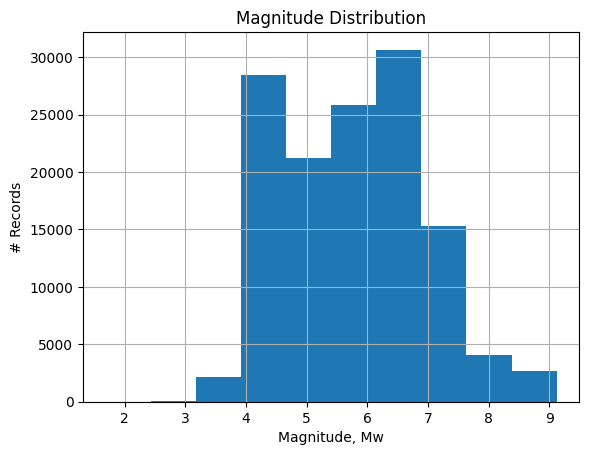

In [27]:
ax = final_db[("metadata", "mag")].hist()
ax.set_title("Magnitude Distribution")
ax.set_xlabel("Magnitude, Mw")
ax.set_ylabel("# Records")

Text(0, 0.5, 'Magnitude [Mw]')

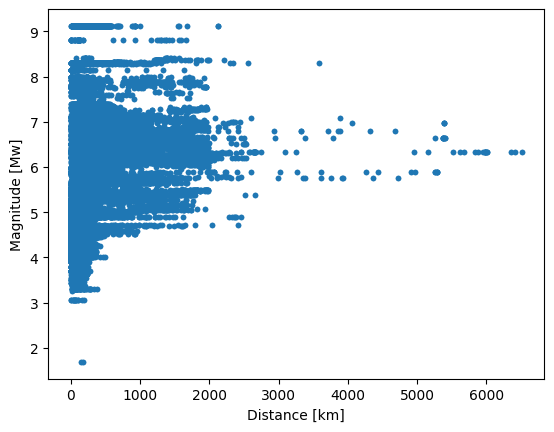

In [28]:
fig, ax = plt.subplots()
ax.scatter(final_db[("metadata", "rjb")], final_db[("metadata", "mag")], marker=".")
ax.set_xlabel("Distance [km]")
ax.set_ylabel("Magnitude [Mw]")
